In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from keras.datasets import mnist
import cv2
np.random.seed(42)

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = np.array([cv2.resize(i, (32,32)) for i in x_train])
x_test = np.array([cv2.resize(i, (32,32)) for i in x_test])


In [2]:
def get_binary_mask(image):
    mask = np.copy(image)
    mask[mask>0.1]=1
    mask[mask!=1]=0
    return mask    

def mnist_binary(x_train,y_train,number_of_instances): 
    if number_of_instances>64:
        number_of_instances = 64
    idx = np.random.choice(np.arange(len(x_train)), number_of_instances)
    imgs = x_train[idx]
    msks = np.array([get_binary_mask(i) for i in imgs])
    
    x,y = np.meshgrid(np.arange(0,256,32),np.arange(0,256,32))
    possible_choices = []
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            possible_choices.append([x[0,i],y[j,0]])
    possible_choices = np.array(possible_choices)        
    
    choices = np.random.choice(len(possible_choices), number_of_instances, replace = False)
    choices = possible_choices[choices,:]  
    
    msk = np.zeros((256,256))
    img = np.zeros((256,256))    
    
    for k in range(number_of_instances):
        x_i = choices[k,0]
        y_i = choices[k,1]
        x_f = x_i + 32
        y_f = y_i + 32
        img[x_i:x_f,y_i:y_f] = imgs[k]
        msk[x_i:x_f,y_i:y_f] = msks[k]        
    
    gaussian_noise = np.random.normal(0, 127.5, img.shape).astype(np.float32)
    # Add the noise to the image
    noisy_img = img.astype(np.float32) + gaussian_noise
    noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)    
    blurred_img = cv2.GaussianBlur(noisy_img, (5, 5), sigmaX=0)
    
    return blurred_img, msk


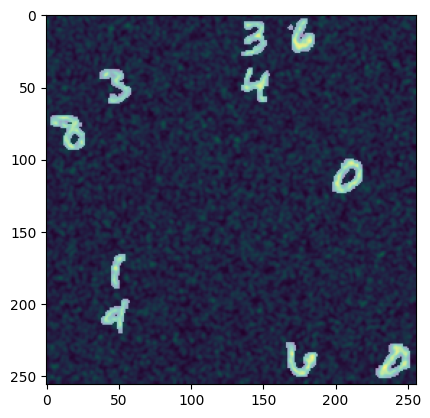

In [3]:
number_of_instances = 10
img, msk = mnist_binary(x_train,y_train,number_of_instances)

fig, ax = plt.subplots()
ax.imshow(img)
ax.imshow(msk, cmap = 'gray', alpha = 0.5)

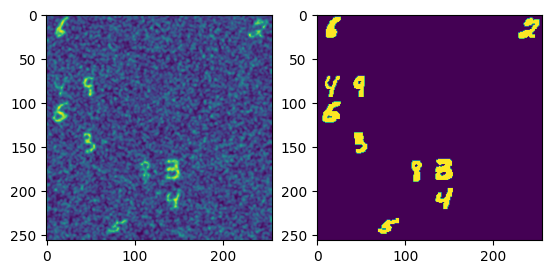

In [4]:
############## Create Training/Testing Data ##############
number_of_instances = np.arange(5,20)
train = [mnist_binary(x_train,y_train,np.random.choice(number_of_instances)) for i in range(1000)]
train_imgs = np.array([np.expand_dims(i[0], axis = -1)/255.0 for i in train])
train_msks = np.array([np.expand_dims(i[1], axis = -1)/1.0 for i in train])
del train

test = [mnist_binary(x_train,y_train,np.random.choice(number_of_instances)) for i in range(100)]
test_imgs = np.array([np.expand_dims(i[0], axis = -1)/255.0 for i in test])
test_msks = np.array([np.expand_dims(i[1], axis = -1)/1.0 for i in test])
del test
del x_train, y_train, x_test, y_test,number_of_instances 

plt.figure()
plt.subplot(1,2,1)
plt.imshow(train_imgs[0])
plt.subplot(1,2,2)
plt.imshow(train_msks[0])

In [5]:
############## Segmentation Model ##############
def build_segmentation_model():
    input_img = layers.Input(shape=(256, 256, 1))  

    # Encoder (Downsampling)
    c1 = layers.Conv2D(16, 3, strides=2, padding='same', activation = 'relu')(input_img) #128
    c2 = layers.Conv2D(32, 3, strides=2, padding='same', activation = 'relu')(c1) # 64
    c3 = layers.Conv2D(64, 3, strides=2, padding='same', activation = 'relu')(c2) # 32
    c4 = layers.Conv2D(128, 3, strides=2, padding='same', activation = 'relu')(c3) # 16
    c5 = layers.Conv2D(256, 3, strides=2, padding='same', activation = 'relu')(c4) # 8
    c6 = layers.Conv2D(512, 3, strides=2, padding='same', activation = 'relu')(c5) # 4
    c7 = layers.Conv2D(1024, 3, strides=2, padding='same', activation = 'relu')(c6) # 2
    
    
    # bottleneck
    bottleneck = layers.Conv2D(1024, 3, activation='relu', strides=2, padding='same')(c7)  #1    
   
    # Decoder (Upsampling)
    d1 = layers.Conv2DTranspose(1024, 3, strides=2, padding='same', activation = 'relu')(bottleneck) #2
    d1 = layers.concatenate([d1, c7])

    d2 = layers.Conv2DTranspose(512, 3, strides=2, padding='same', activation = 'relu')(d1) #4
    d2 = layers.concatenate([d2, c6])
    
    d3 = layers.Conv2DTranspose(256, 3, strides=2, padding='same', activation = 'relu')(d2) #8
    d3 = layers.concatenate([d3, c5])
    
    d4 = layers.Conv2DTranspose(128, 3, strides=2, padding='same', activation = 'relu')(d3) #16
    d4 = layers.concatenate([d4, c4])
    
    d5 = layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation = 'relu')(d4) #32
    d5 = layers.concatenate([d5, c3])
    
    d6 = layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation = 'relu')(d5) #64
    d6 = layers.concatenate([d6, c2])
    
    d7 = layers.Conv2DTranspose(16, 3, strides=2, padding='same', activation = 'relu')(d6) #128
    d7 = layers.concatenate([d7, c1])          
    
    # Output layer
    output = layers.Conv2DTranspose(1, (3, 3), activation='sigmoid', strides=2, padding='same')(d7)     
    model = models.Model(inputs=input_img, outputs=output)
    model.summary()        
    return model

In [6]:
model = build_segmentation_model()
model.compile(optimizer='adam', loss='bce', metrics = 'bce')

history = model.fit(train_imgs, train_msks, batch_size = 32, epochs = 20, validation_split = 0.2)

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 256, 256, 1) 0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, 128, 128, 16) 160         input_1[0][0]                    
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 64, 64, 32)   4640        conv2d[0][0]                     
__________________________________________________________________________________________________
conv2d_2 (Conv2D)               (None, 32, 32, 64)   18496       conv2d_1[0][0]                   
______________________________________________________________________________________________

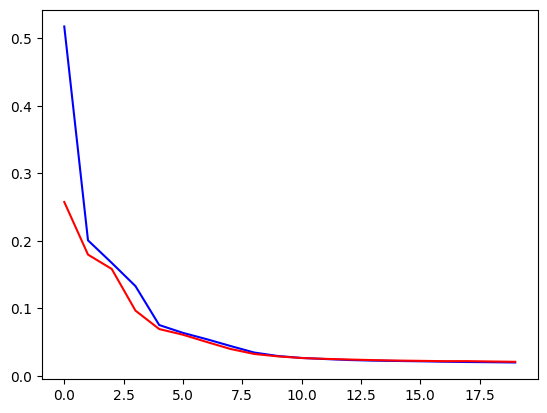

In [7]:
plt.figure()
plt.plot(history.history['loss'], c = 'b')
plt.plot(history.history['val_loss'], c = 'r')

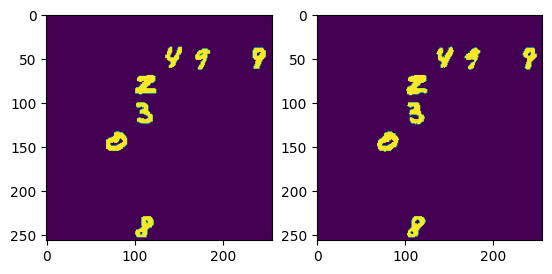

In [8]:
############ Model Predictions ############
predictions = model.predict(test_imgs)
predictions[predictions<0.5]=0
predictions[predictions>=0.5]=1

plt.figure()
plt.subplot(1,2,1)
plt.imshow(test_msks[10])
plt.subplot(1,2,2)
plt.imshow(predictions[10])

In [9]:
def calculate_cm(mask,pred,number_of_classes):
    # this function takes in a predicted segmentation mask and an annotated ground truth mask for a k-class segmentation task
    # to calculate confusion matrix, the rows are the ground-turth labels and the columns are the predictions       
    if mask.shape == pred.shape:
        mask = mask.flatten()
        pred = pred.flatten()
        cm = np.zeros((number_of_classes,number_of_classes))
        for i in range(number_of_classes):
            for j in range(number_of_classes):
                cm[i,j] = np.sum(np.logical_and(mask==i, pred==j))
        return cm
    else:
        print('The prediction and the ground truth segmentation masks are of different size')
        return []

def calculate_dice_binary_matrix(cm):  
    if np.sum(cm, axis =1)[0] ==0:
        dice = np.nan  
    else:
        dice = 2*cm[0, 0]/(2*cm[0, 0] + cm[0, 1] + cm[1, 0])  
    return dice

def convert_m_by_m_matrix_to_2_by_2(mat, index = 3):
    mat_copy = np.copy(mat)
    mat_copy[[index,0],:] = mat_copy[[0,index],:]  
    mat_copy[:,[index,0]] = mat_copy[:,[0,index]]  
    two_by_two_matrix = np.zeros((2,2))
    two_by_two_matrix[0,0] = mat_copy[0,0]
    two_by_two_matrix[0,1] = np.sum(mat_copy[0,1:])
    two_by_two_matrix[1,0] = np.sum(mat_copy[1:,0])
    two_by_two_matrix[1,1] = np.sum(mat_copy[1:,1:])    
    return two_by_two_matrix

def calculate_dice(cm, class_index):
    # CM is a numpy array of size (k,k) where k is the number of class labels
    # If the ground truth label does not contain a class label, a DICE of NA is obtained for that class.
    # dice_val is returned for class k
    cm_conv = convert_m_by_m_matrix_to_2_by_2(cm, index = class_index)
    dice_val = calculate_dice_binary_matrix(cm_conv)
    return dice_val

In [10]:
cm = [calculate_cm(test_msks[i],predictions[i],number_of_classes=2) for i in range(100)]
dice = [calculate_dice(cm[i], class_index=1) for i in range(100)]
print('Dice = '+str(np.round(np.mean(dice),2))+' ['+str(np.round(np.percentile(dice,2.5),2))+', '+str(np.round(np.percentile(dice,97.5),2))+'] 95% CI')

Dice = 0.91 [0.89, 0.93] 95% CI
